# Classification example (multi.output)


In [ ]:
import shap
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml



Business as Usual: load, clean train

In [ ]:

# Load Palmer Penguins dataset
df = pd.read_csv("https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv")
df = df.dropna()
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = df['species']


In [ ]:

# Encode target and split
y = y.astype('category').cat.codes
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)


In [ ]:

# Train logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
model = LogisticRegression(multi_class='multinomial', max_iter=1000)
model.fit(X_train_scaled, y_train)


ExAI

Dependance Scatter plots

**What the Plot Shows**
This is a dependence scatter plot:
X-axis: The actual feature value, e.g., the flipper length in millimetres.
Y-axis: The SHAP value for that feature, i.e., how much that flipper length contributes to the prediction for class 0 (e.g., Adelie).
Each dot is an individual prediction/sample.

**Interpreting the Trend**
If the points form a downward slope, it indicates a negative (inverse) relationship:
As flipper length increases, the SHAP value decreases.
In other words, longer flippers reduce the model’s confidence in class 0.
If the points slope upward, it indicates a positive relationship:
Larger flipper values increase the prediction probability for class 0.
SHAP values are additive contributions to the logit (log-odds), so the trend can be interpreted as a directional influence.

The Grey Histogram at the Bottom is a marginal histogram of the feature's value in the test set. It gives context for where the model sees more or fewer examples—useful for judging how confident you should be about the observed trend.


['Feature 0', 'Feature 1', 'Feature 2', 'Feature 3']


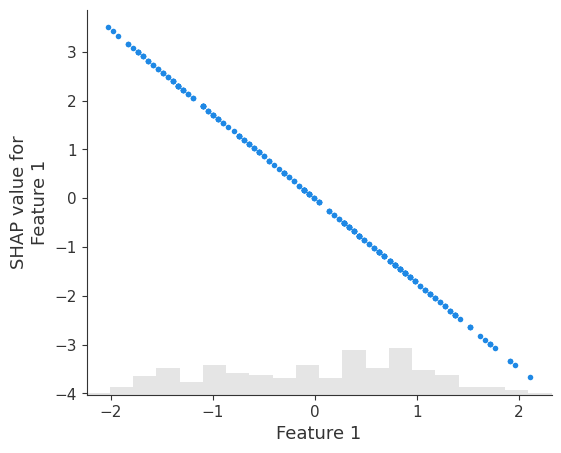

In [5]:

# SHAP explanation
explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer(X_train_scaled)

# Visualise
print(shap_values.feature_names)

shap.plots.scatter(shap_values[:, 1][:, 2])


Waterfall plots

A SHAP waterfall chart explains how the features of a single instance contribute to a specific model output (in classification: the log-odds or probability for one class).

data structure: (samples, classes, features)


**How to Read the Chart**
Base value (at the bottom):
The expected model output (log-odds) for class 0 over the entire dataset — the baseline prediction if no features were known.
Feature bars (middle):
Each feature either increases (red bars) or decreases (blue bars) the model’s output for class 0 relative to the base value.
Final value (at the top):
The model’s predicted log-odds for class 0 for this instance.


You’re seeing exactly why the model believed this penguin should (or shouldn’t) belong to class 0, and which features drove that decision.














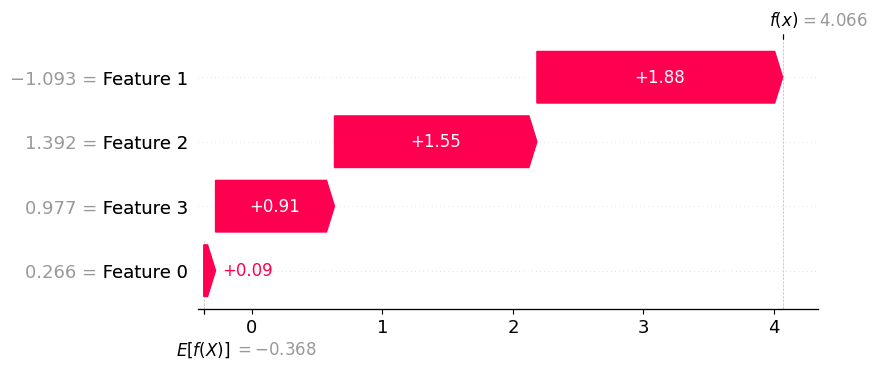

In [7]:
shap.plots.waterfall(shap_values[2][:, 2]) #  [sampleID][:, label]

Summary plot

The SHAP summary plot is a compact visualisation that summarises global feature importance and the distribution of feature effects across your dataset.

What the Bar Plot Shows
Each bar corresponds to a feature.

Bar length represents the mean absolute SHAP value for that feature across all samples.

This is a measure of overall feature importance: how much that feature contributes, on average, to the model’s output magnitude (regardless of direction).





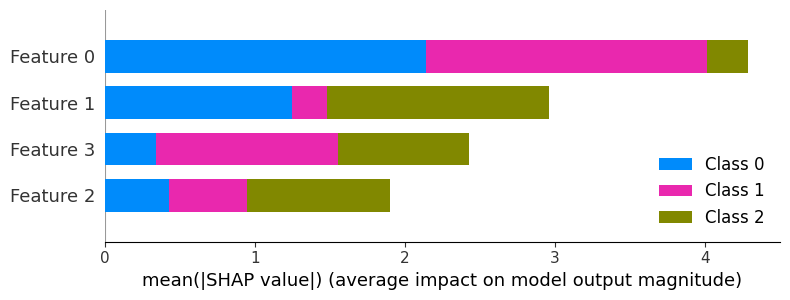

In [8]:
shap.summary_plot(shap_values, X_train_scaled)


# Regression example (one output)

In [9]:

import shap
import sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

# Load dataset
data = pd.read_csv("https://raw.githubusercontent.com/sonarsushant/California-House-Price-Prediction/refs/heads/master/housing.csv")
data = data.dropna()
#print(data)

X = data[["housing_median_age","total_rooms","total_bedrooms","population","households","median_income"]]
y = data.median_house_value

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Train a simple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
# Use k-means to summarise background dataset for KernelExplainer
background = shap.kmeans(X_train, 50)  # 50 clusters

# Create KernelExplainer with summarized background
explainer = shap.KernelExplainer(model.predict, background)

shap_values = explainer.shap_values(X_train.iloc[:100, :])

  0%|          | 0/100 [00:00<?, ?it/s]

Summary pot (dot style)

What the Plot Shows
Y-axis: Features, ordered from most to least important (based on mean absolute SHAP values).

Each dot: A single data point’s SHAP value for that feature.

X-axis: SHAP value — the contribution of that feature to pushing the prediction higher (positive) or lower (negative).

Colour of each dot: The original feature value (e.g., blue for low values, red for high values).

How to Interpret It
A dot far to the right means the feature strongly pushes the prediction higher for that sample.

A dot far to the left means the feature strongly pushes the prediction lower.

Colour gradients show how feature value relates to its effect:

If red dots are mostly right, high values increase predictions.

If red dots are mostly left, high values decrease predictions.

The vertical spread of dots per feature shows variation in effect across samples.

Overlapping dots form dense regions, indicating many similar SHAP values.

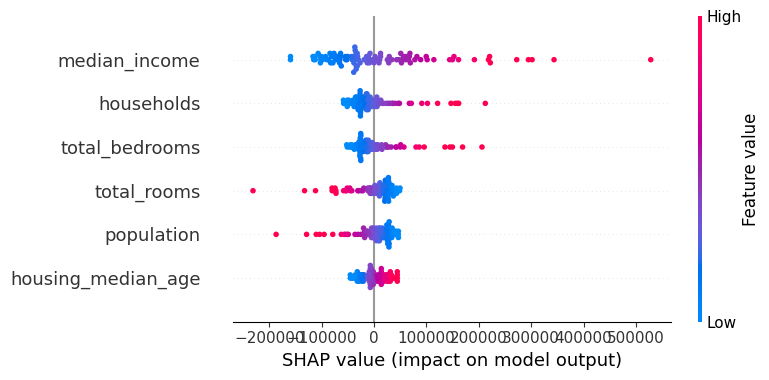

In [11]:

# Summary plot
shap.summary_plot(shap_values, X_train.iloc[:100, :], plot_type="dot")


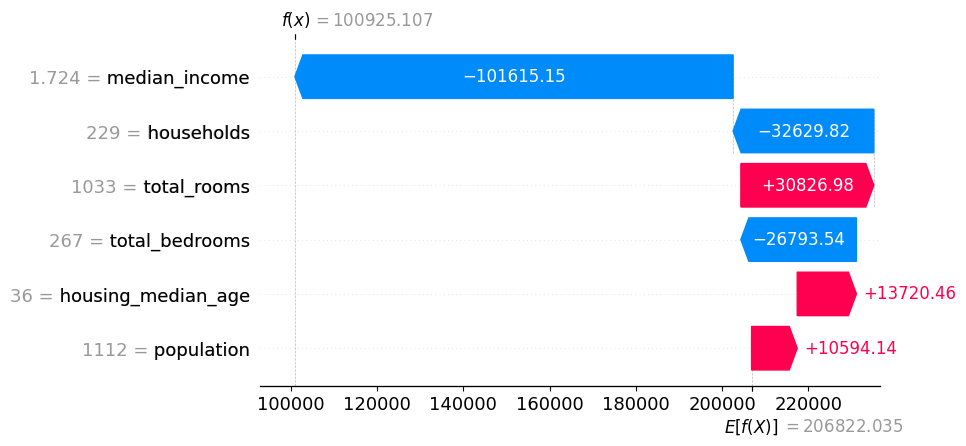

In [12]:
# Waterfall plot for first instance
shap.plots.waterfall(shap.Explanation(values=shap_values[0],
                                     base_values=explainer.expected_value,
                                     data=X_train.iloc[0, :]))

Force plot

What the Force Plot Shows
The base value (usually in the center) is the average model output over the background dataset — think of it as the baseline prediction before seeing any features.

The final prediction for the instance is shown at the right (or left, depending on value).

Arrows or colored bars represent feature contributions pushing the prediction up (towards higher values, often red) or down (towards lower values, often blue).

The length of each arrow corresponds to the magnitude of the feature’s impact.

Features are stacked to show cumulative effect from the base value to the prediction.



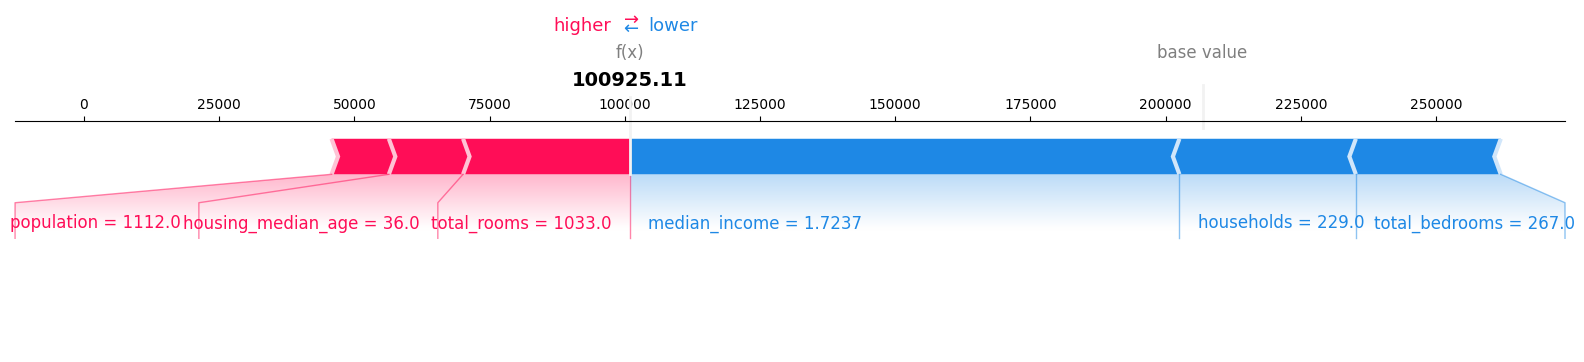

In [13]:
# Create the force plot for the first instance
shap.force_plot(
    explainer.expected_value,          # base value
    shap_values[0],                    # SHAP values for first  instance
    X_train.iloc[0, :],             # feature values for first  instance
    matplotlib=True                    # plot inline with matplotlib
)